### **Amdahl's Law 1**

Suppose that a specific task consists of two subtasks. The first subtask retrieves data from a file; it takes 20 seconds to execute on a given system, and it cannot be parallelized. The second subtask processes a large number of data records; it takes 100 seconds to execute sequentially. Each data record can be processed independently, so the second subtask is easily parallelized.

1. What is the parallel fraction of the task consisting of the two subtasks?

2. What is the theoretical speedup for $p=10$ processors?

3. What is the theoretical maximum speedup?

4. Imagine we currently have 4 processors available for parallization. To improve performance, we have two options:

    1. Optimize the first subtask so we can retrieve the data from the file in 5 seconds instead of 20.

    2. Purchase more processors so we have 8 processors available instead of 4.

    Which option will provide the shortest runtime?

**1. answer:**

FIRST TASK $20$ seconds to execute on a system, cannot be parallelized. SECOND TASK $100$ seconds, can be parrallelized. We use the formula:
$$
S(p) = \frac{1}{(1-F)+\frac{F}{p}} = \frac{1}{B+\frac{1-B}{p}}
$$
We have to find $F$ which is the fraction of the program that can be parallelized, and our program is in total $120 \: s$ and $100 \: s$ can be parallelized, so $F = \frac{100}{120} = \frac{5}{6}$.

**2. answer:**

Now we insert $F=\frac{5}{6}$ and $p=10$ into the formula:
$$
S(p)= \frac{1}{(1-\frac{5}{6})+\frac{\frac{5}{6}}{10}} = \frac{1}{\frac{1}{6}+\frac{5}{60}} = \frac{1}{\frac{1}{6}+\frac{1}{12}} = \frac{1}{\frac{2}{12}+\frac{1}{12}} = \frac{1}{\frac{3}{12}} = 4
$$
So $4$ is the answer.

**3. answer:**

We use the formula:
$$
S(\infty) = \frac{1}{1-F}
$$
We insert:
$$
=\frac{1}{1-\frac{5}{6}} = \frac{1}{\frac{1}{6}} = 6
$$

### **Parralel pi 1**

The goal of this exercise is to use parallelization to improve the performance of our code. We will use the Monte Carlo approximation of pi from Advanced Python Programming, Chapter 7. Let's take a look at the three different implementations from Advanced Python Programming:

Implementation 1: Fully serial
```python
import random

samples = 1000000
hits = 0

for i in range(samples):
    x = random.uniform(-1.0, 1.0)
    y = random.uniform(-1.0, 1.0)
    if x**2 + y**2 <= 1:
        hits += 1

pi = 4.0 * hits/samples
```
Implementation 2: Fully parallel
```Python
import random
import multiprocessing

def sample():
    x = random.uniform(-1.0, 1.0)
    y = random.uniform(-1.0, 1.0)
    if x**2 + y**2 <= 1:
        return 1
    else:
        return 0

if __name__ == '__main__':
    samples = 1000000
    hits = 0

    n_proc = 10
    pool = multiprocessing.Pool(n_proc)
    results_async = [pool.apply_async(sample) for i in range(samples)]
    hits = sum(r.get() for r in results_async)
    pi = 4.0 * hits/samples
```
Implementation 3: Chunked parallel
```python
import random
import multiprocessing

def sample():
    x = random.uniform(-1.0, 1.0)
    y = random.uniform(-1.0, 1.0)
    if x**2 + y**2 <= 1:
        return 1
    else:
        return 0

def sample_multiple(samples_partial):
    return sum(sample() for i in range(samples_partial))

if __name__ == '__main__':
    samples = 1000000
    hits = 0

    n_proc = 10
    chunk_size = samples//n_proc
    pool = multiprocessing.Pool(n_proc)
    results_async = [pool.apply_async(sample_multiple, (chunk_size,))
                    for i in range(n_proc)]
    hits = sum(r.get() for r in results_async)
    pi = 4.0 * hits/samples
```

### **Parralel pi 2**

See autolab.

### **Parralel pi 3**

The chunked parallel one is fastest.

```
real	0m0.744s
user	0m0.715s
sys	0m0.011s

real	0m55.444s
user	1m18.814s
sys	0m31.231s

real	0m0.214s
user	0m0.792s
sys	0m0.060s
```
Now we write the script for the plot below using speedup formula $Speedup(p) = T1 / Tp$.

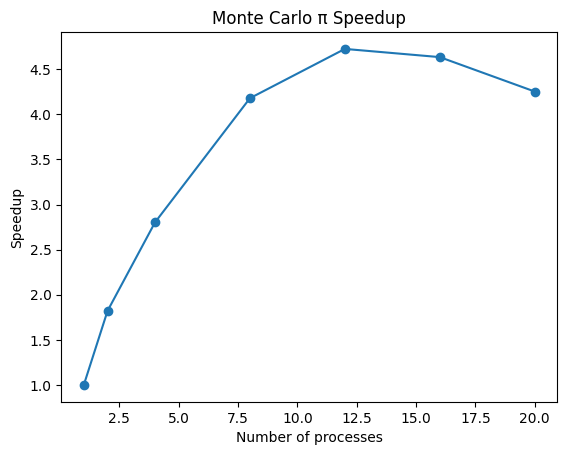

In [4]:
import matplotlib.pyplot as plt

processes = [1,2,4,8,12,16,20]

speedup = [
    0.723/0.723,
    0.723/0.397,
    0.723/0.258,
    0.723/0.173,
    0.723/0.153,
    0.723/0.156,
    0.723/0.170
]

plt.plot(processes, speedup, marker='o')
plt.xlabel("Number of processes")
plt.ylabel("Speedup")
plt.title("Monte Carlo π Speedup")

plt.show()

### **Parralel pi 4**

We have to use amdhal's law given as:
$$
S(p) = \frac{1}{(1 - F) + \frac{F}{p}}
$$
We also check out our speedup values.

In [5]:
print(speedup)

[1.0, 1.8211586901763224, 2.8023255813953485, 4.179190751445087, 4.7254901960784315, 4.634615384615384, 4.252941176470588]


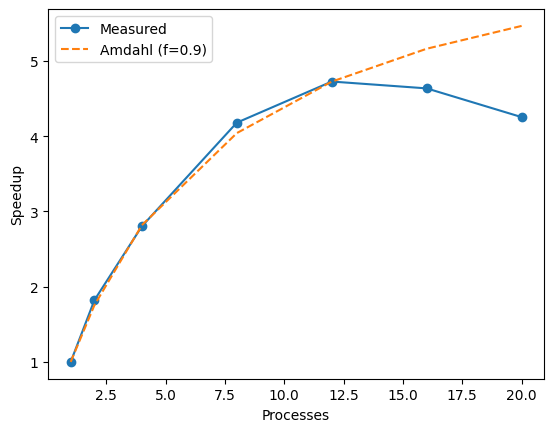

In [13]:
import matplotlib.pyplot as plt
import numpy as np

p = np.array([1,2,4,8,12,16,20])
measured = speedup

f = 0.86
amdahl = 1 / ((1-f) + f/p)

plt.plot(p, measured, 'o-', label="Measured")
plt.plot(p, amdahl, '--', label="Amdahl (f=0.9)")

plt.xlabel("Processes")
plt.ylabel("Speedup")
plt.legend()

plt.show()

### **Parralel pi 5**

This one is optional.

### **The Mandelbrot Set 1**

We are given:
```python
import multiprocessing
import numpy as np
import matplotlib.pyplot as plt

def mandelbrot_escape_time(c):
    z = 0
    for i in range(100):
        z = z**2 + c
        if np.abs(z) > 2.0:
            return i
    return 100

def generate_mandelbrot_set(points, num_processes):
    ########################
    # YOUR CODE HERE #
    ########################
    return escape_times

def plot_mandelbrot(escape_times):
    plt.imshow(escape_times, cmap='hot', extent=(-2, 2, -2, 2))
    plt.axis('off')
    plt.savefig('mandelbrot.png', bbox_inches='tight', pad_inches=0)

if __name__ == "__main__":
    width = 800
    height = 800
    xmin, xmax = -2, 2
    ymin, ymax = -2, 2
    num_proc = 4

    # Precompute points
    x_values = np.linspace(xmin, xmax, width)
    y_values = np.linspace(ymin, ymax, height)
    points = np.array([complex(x, y) for x in x_values for y in y_values])

    # Compute set
    mandelbrot_set = generate_mandelbrot_set(points, num_proc)

    # Save set as image
    mandelbrot_set = mandelbrot_set.reshape((height, width))
    plot_mandelbrot(mandelbrot_set)
```
Implement the function `generate_mandelbrot_set` to compute the escape times for each complex number in parallel. The function must return a NumPy array. Distribute the points equally between all the processors. Hint: adapt the chunked parallel implementation from the previous exercise.

### **The Mandelbrot Set 2**

See shell file.

### **The Mandelbrot Set 3**

Inserted in `mandelbrot.py`, where we just have fixed chunk size `chunk_size = 1000 # fixed chunk size`.

### **The Mandelbrot Set 4**

:)

### **Mean Faces 1**

See python file.

### **Mean Faces 2**

### **Mean Faces 3**

### **Mean Faces 4**

### **Mean Faces 5**

### **Mean Faces 6**